In [ ]:
# LinkedIn Data Visualization Dashboard
# Block 1: Import packages and setup database connection

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For advanced plotting
from matplotlib.patches import Polygon
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

✅ All packages imported successfully!


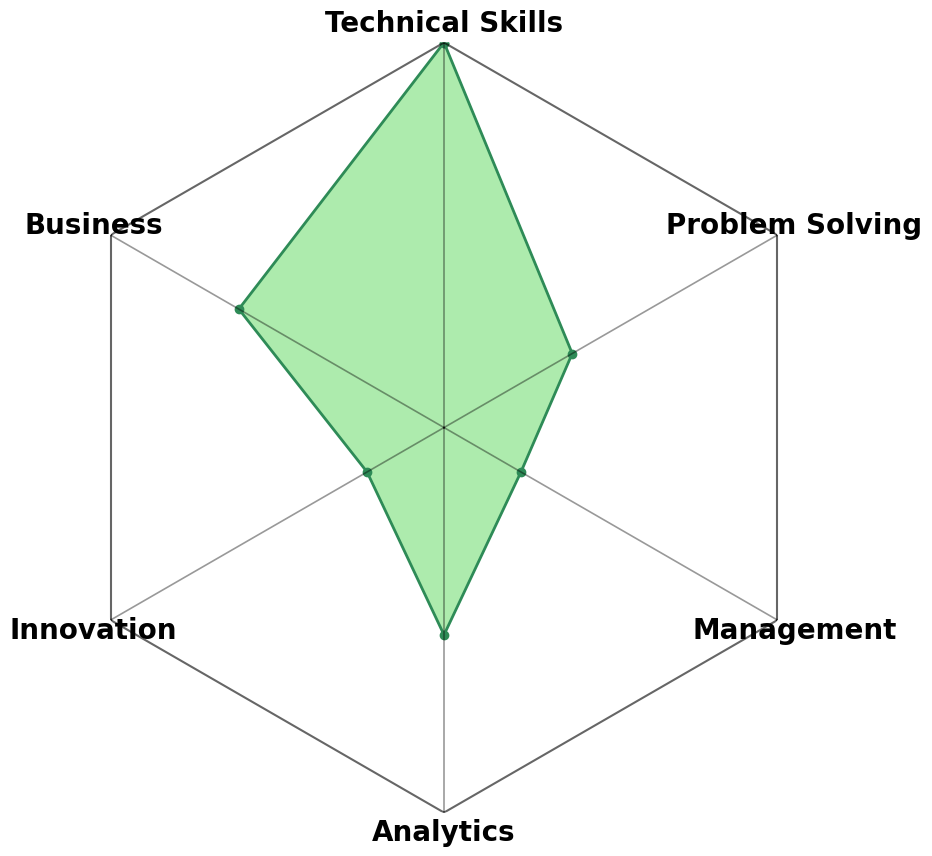

In [16]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

def find_sports_buddies_directory():
    current_path = os.getcwd()
    if os.path.basename(current_path) == "sports-buddies" and os.path.exists("data"):
        return current_path
    sports_buddies_path = os.path.join(current_path, "sports-buddies")
    if os.path.exists(sports_buddies_path) and os.path.exists(os.path.join(sports_buddies_path, "data")):
        os.chdir(sports_buddies_path)
        return sports_buddies_path
    check_path = current_path
    for _ in range(5):
        parent_path = os.path.dirname(check_path)
        if parent_path == check_path:
            break
        sports_buddies_path = os.path.join(parent_path, "sports-buddies")
        if os.path.exists(sports_buddies_path) and os.path.exists(os.path.join(sports_buddies_path, "data")):
            os.chdir(sports_buddies_path)
            return sports_buddies_path
        check_path = parent_path
    return None

find_sports_buddies_directory()

try:
    with open("data/cur_user_selected.txt", "r", encoding="utf-8") as f:
        user = int(f.read().strip())
except FileNotFoundError:
    user = 8

linkedin_data = None

try:
    with open("data/event_data.json", "r", encoding="utf-8") as f:
        event_data = json.load(f)
    try:
        linkedin_data = event_data["payload"]["linkedin"]["payload"]["linkedin"]
    except (KeyError, TypeError):
        linkedin_data = event_data["payload"]["linkedin"]
except FileNotFoundError:
    pass

if linkedin_data is None:
    try:
        with open("data/test.json", "r", encoding="utf-8") as f:
            linkedin_data = json.load(f)
    except FileNotFoundError:
        pass

if linkedin_data is None:
    linkedin_data = {
        "skills": [
            "Microsoft Power BI", "Web Development", "Tableau", "Data Analytics", 
            "Data-driven Decision Making", "Data Infrastructure", "Computer Science", 
            "Statistics", "Python", "SQL", "Financial Forecasting", "Financial Accounting",
            "Market Analysis", "Business Analysis", "Financial Analysis", "Banking",
            "Programming", "Analytical Skills", "Java", "Digital Marketing", "Javascript",
            "HTML", "CSS", "C++", "Communication", "Critical Thinking", "Time Management",
            "Adobe Director", "Organizational Skills", "Gaming Industry", "Oracle VM",
            "EViews", "IBM SPSS", "Management", "Negotiation", "Problem Solving"
        ]
    }

skills = linkedin_data.get("skills", [])

skill_categories = {
    "Technical Skills": [
        "Python", "Java", "JavaScript", "TypeScript", "C++", "C#", ".NET", "HTML", "CSS", "React", "Angular", 
        "Vue.js", "Node.js", "Django", "Flask", "SQL", "PostgreSQL", "MySQL", "MongoDB", "Git", "GitHub",
        "Docker", "Kubernetes", "AWS", "Azure", "Google Cloud Platform", "Linux", "Shell Scripting",
        "Data Analysis", "Data Science", "Machine Learning", "Deep Learning", "Artificial Intelligence",
        "Natural Language Processing", "NLP", "Computer Vision", "Big Data", "ETL", "Data Engineering",
        "Tableau", "Power BI", "Statistics", "Programming", "Web Development", "Database Design"
    ],
    "Problem Solving": [
        "Problem Solving", "Critical Thinking", "Analytical Thinking", "Creative Thinking", "Decision Making",
        "Strategic Thinking", "Innovation", "Research", "Troubleshooting", "Debugging", "Root Cause Analysis",
        "Process Improvement", "Algorithm Design", "Systems Thinking", "Design Thinking", "User Experience",
        "Requirements Analysis", "Business Analysis", "Risk Assessment", "Analytical Skills"
    ],
    "Management": [
        "Project Management", "Product Management", "Leadership", "Team Leadership", "People Management",
        "Change Management", "Risk Management", "Resource Management", "Budget Management", "Financial Management",
        "Stakeholder Management", "Agile", "Scrum", "Kanban", "Strategic Planning", "Business Planning",
        "Performance Management", "Training", "Coaching", "Mentoring", "Management", "Organizational Skills"
    ],
    "Analytics": [
        "Data Analytics", "Business Intelligence", "Statistical Analysis", "Predictive Analytics",
        "Data Visualization", "Data Mining", "Financial Analysis", "Market Analysis", "Customer Analytics",
        "Financial Forecasting", "Financial Accounting", "Operations Research", "IBM SPSS", "EViews"
    ],
    "Innovation": [
        "Innovation", "Creative Thinking", "Design Thinking", "Digital Marketing", "Adobe Director",
        "Gaming Industry", "Creativity", "Product Strategy", "Digital Transformation"
    ],
    "Business": [
        "Business Analysis", "Financial Analysis", "Market Analysis", "Banking", "Negotiation",
        "Communication", "Time Management", "Business Planning", "Commercial Awareness"
    ]
}

skill_counts = {}
skill_details = {}

for category, category_skills in skill_categories.items():
    count = 0
    matched_skills = []
    for user_skill in skills:
        user_skill_lower = user_skill.lower()
        for category_skill in category_skills:
            category_skill_lower = category_skill.lower()
            if (category_skill_lower == user_skill_lower or 
                category_skill_lower in user_skill_lower or 
                user_skill_lower in category_skill_lower):
                count += 1
                matched_skills.append(user_skill)
                break
    skill_counts[category] = count
    skill_details[category] = matched_skills

total_skills = len(skills)
skill_percentages = {cat: (count / total_skills * 100) if total_skills > 0 else 0 
                    for cat, count in skill_counts.items()}

def create_hexagon_skills_chart(skill_percentages):
    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, projection='polar')
    categories = list(skill_percentages.keys())
    values = [skill_percentages[cat] for cat in categories]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    ax.fill(angles, values, color='#32CD32', alpha=0.4)
    ax.plot(angles, values, color='#2E8B57', linewidth=2, marker='o')

    max_radius = max(values) if max(values) > 0 else 100
    ax.set_ylim(0, max_radius)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=20, fontweight='bold')
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_rticks([])
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, max_radius], 'k-', lw=1.2, alpha=0.4)

    # Specific connections as requested
    category_to_index = {cat: i for i, cat in enumerate(categories)}
    
    # Technical Skills to Business and Problem Solving
    tech_idx = category_to_index["Technical Skills"]
    business_idx = category_to_index["Business"]
    problem_idx = category_to_index["Problem Solving"]
    
    ax.plot([angles[tech_idx], angles[business_idx]], [max_radius, max_radius], 'k-', lw=1.5, alpha=0.6)
    ax.plot([angles[tech_idx], angles[problem_idx]], [max_radius, max_radius], 'k-', lw=1.5, alpha=0.6)
    
    # Innovation to Business and Analytics
    innovation_idx = category_to_index["Innovation"]
    analytics_idx = category_to_index["Analytics"]
    
    ax.plot([angles[innovation_idx], angles[business_idx]], [max_radius, max_radius], 'k-', lw=1.5, alpha=0.6)
    ax.plot([angles[innovation_idx], angles[analytics_idx]], [max_radius, max_radius], 'k-', lw=1.5, alpha=0.6)
    
    # Management to Analytics and Problem Solving
    management_idx = category_to_index["Management"]
    
    ax.plot([angles[management_idx], angles[analytics_idx]], [max_radius, max_radius], 'k-', lw=1.5, alpha=0.6)
    ax.plot([angles[management_idx], angles[problem_idx]], [max_radius, max_radius], 'k-', lw=1.5, alpha=0.6)

    return fig

fig = create_hexagon_skills_chart(skill_percentages)
plt.show()

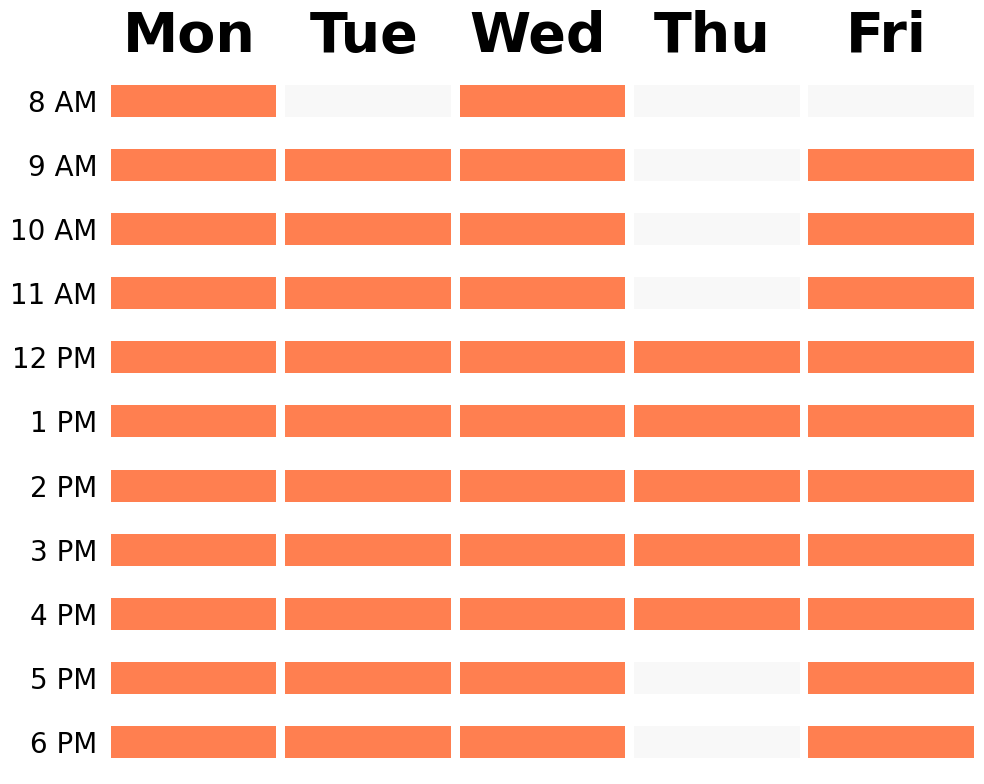

In [17]:
# Task 2: Working Time Chart
# Create a heatmap showing working hours across the week

def find_sports_buddies_directory():
    current_path = os.getcwd()
    if os.path.basename(current_path) == "sports-buddies" and os.path.exists("data"):
        return current_path
    sports_buddies_path = os.path.join(current_path, "sports-buddies")
    if os.path.exists(sports_buddies_path) and os.path.exists(os.path.join(sports_buddies_path, "data")):
        os.chdir(sports_buddies_path)
        return sports_buddies_path
    check_path = current_path
    for _ in range(5):
        parent_path = os.path.dirname(check_path)
        if parent_path == check_path:
            break
        sports_buddies_path = os.path.join(parent_path, "sports-buddies")
        if os.path.exists(sports_buddies_path) and os.path.exists(os.path.join(sports_buddies_path, "data")):
            os.chdir(sports_buddies_path)
            return sports_buddies_path
        check_path = parent_path
    return None

find_sports_buddies_directory()

try:
    with open("data/cur_user_selected.txt", "r", encoding="utf-8") as f:
        user = int(f.read().strip())
except FileNotFoundError:
    user = 8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def create_working_time_chart():
    # Your specific schedule
    schedule = {
        'Mon': [(8, 19)],  # 8 AM to 6 PM
        'Tue': [(9, 19)],  # 9 AM to 6 PM
        'Wed': [(8, 19)],  # 8 AM to 6 PM
        'Thu': [(12, 17)], # 12 PM to 4 PM
        'Fri': [(9, 19)]   # 9 AM to 6 PM
    }
    
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    hours = list(range(8, 19))  # 8 AM to 6 PM
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define colors
    active_color = '#FF7F50'  # Coral orange
    inactive_color = '#F8F8F8'  # Super light gray
    
    # Draw rectangles for each hour and day
    for day_idx, day in enumerate(days):
        for hour_idx, hour in enumerate(hours):
            # Check if this hour is in the working schedule
            is_working = False
            if day in schedule:
                for start_hour, end_hour in schedule[day]:
                    if start_hour <= hour < end_hour:
                        is_working = True
                        break
            
            # Choose color
            color = active_color if is_working else inactive_color
            
            # Create rectangle with 1px spacing and specified dimensions
            rect = patches.Rectangle(
                (day_idx + 0.05, hour_idx + 0.25),  # x, y with 1px spacing
                0.95,  # width = 1.0 - 0.1 (for spacing)
                0.5,  # height = 0.5
                linewidth=0,
                facecolor=color,
                edgecolor='white',
            )
            ax.add_patch(rect)
    
    # Set axis properties
    ax.set_xlim(0, len(days))
    ax.set_ylim(0, len(hours))
    
    # Set ticks and labels
    ax.set_xticks([i + 0.5 for i in range(len(days))])
    ax.set_xticklabels(days, fontsize=40, fontweight='bold')
    ax.xaxis.tick_top()  # Move x-axis to top
    
    ax.set_yticks([i + 0.5 for i in range(len(hours))])
    hour_labels = []
    for hour in hours:
        if hour < 12:
            hour_labels.append(f'{hour} AM')
        elif hour == 12:
            hour_labels.append('12 PM')
        else:
            hour_labels.append(f'{hour-12} PM')
    ax.set_yticklabels(hour_labels, fontsize=20)
    
    # Remove spines and ticks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    
    # Invert y-axis so 8 AM is at the top
    ax.invert_yaxis()
    
    plt.tight_layout()
    return fig

fig = create_working_time_chart()
plt.show()

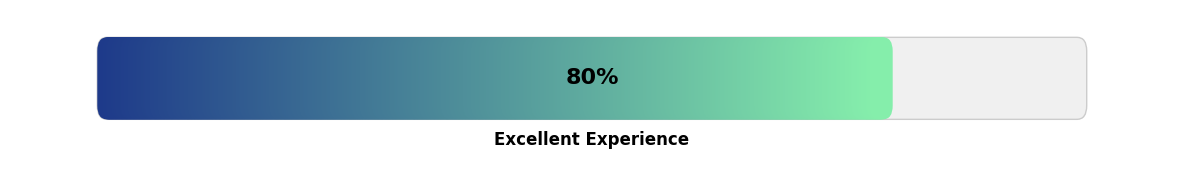

In [18]:
# Task 3: Job Stability Progress Bar
# Calculate job stability score and create progress bar with rounded corners

def find_sports_buddies_directory():
    current_path = os.getcwd()
    if os.path.basename(current_path) == "sports-buddies" and os.path.exists("data"):
        return current_path
    sports_buddies_path = os.path.join(current_path, "sports-buddies")
    if os.path.exists(sports_buddies_path) and os.path.exists(os.path.join(sports_buddies_path, "data")):
        os.chdir(sports_buddies_path)
        return sports_buddies_path
    check_path = current_path
    for _ in range(5):
        parent_path = os.path.dirname(check_path)
        if parent_path == check_path:
            break
        sports_buddies_path = os.path.join(parent_path, "sports-buddies")
        if os.path.exists(sports_buddies_path) and os.path.exists(os.path.join(sports_buddies_path, "data")):
            os.chdir(sports_buddies_path)
            return sports_buddies_path
        check_path = parent_path
    return None

find_sports_buddies_directory()

try:
    with open("data/cur_user_selected.txt", "r", encoding="utf-8") as f:
        user = int(f.read().strip())
except FileNotFoundError:
    user = 8

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datetime import datetime

# Load LinkedIn data to get job history
linkedin_data = None

try:
    with open("data/event_data.json", "r", encoding="utf-8") as f:
        event_data = json.load(f)
    try:
        linkedin_data = event_data["payload"]["linkedin"]["payload"]["linkedin"]
    except (KeyError, TypeError):
        linkedin_data = event_data["payload"]["linkedin"]
except FileNotFoundError:
    pass

if linkedin_data is None:
    try:
        with open("data/test.json", "r", encoding="utf-8") as f:
            linkedin_data = json.load(f)
    except FileNotFoundError:
        pass

if linkedin_data is None:
    linkedin_data = {
        "experience": [
            {
                "position": "Working Student Central Workforce Growth",
                "company": "Flink",
                "start_date": "May 2025",
                "end_date": "Present",
                "duration_months": 2
            },
            {
                "position": "Solutions Engineering Associate", 
                "company": "powered by Dexi",
                "start_date": "January 2023",
                "end_date": "September 2024",
                "duration_months": 20
            },
            {
                "position": "Onboarding Programme - Credit Risk Analyst",
                "company": "ProCredit Bank Albania", 
                "start_date": "March 2022",
                "end_date": "January 2023",
                "duration_months": 10
            },
            {
                "position": "System Integration - Mulesoft Bootcamp",
                "company": "Deloitte",
                "start_date": "November 2021", 
                "end_date": "December 2021",
                "duration_months": 1
            }
        ]
    }

def calculate_job_stability_score(experience_data):
    """
    Calculate job stability score for STUDENTS (age ~25):
    More lenient criteria suitable for early career professionals
    """
    
    jobs = experience_data.get("experience", [])
    if not jobs:
        return 0.0
    
    # Extract job durations
    durations = []
    for job in jobs:
        duration = job.get("duration_months", 0)
        durations.append(duration)
    
    # Factor 1: Average job duration (weight: 30%) - RELAXED for students
    avg_duration = np.mean(durations)
    # For students: 6-18 months is good, 18+ months is excellent
    if avg_duration >= 18:
        duration_score = 1.0
    elif avg_duration >= 12:
        duration_score = 0.8
    elif avg_duration >= 6:
        duration_score = 0.6
    else:
        duration_score = avg_duration / 6  # Linear increase to 6 months
    
    # Factor 2: Job progression (weight: 40%) - IMPORTANT for students
    # Students benefit from showing variety and growth
    num_jobs = len(jobs)
    if num_jobs >= 3:
        progression_score = 1.0  # Good variety of experience
    elif num_jobs == 2:
        progression_score = 0.7
    else:
        progression_score = 0.4  # Need more experience
    
    # Factor 3: Recent job quality (weight: 20%)
    # For students, having ANY recent experience is valuable
    current_job_duration = durations[0] if durations else 0
    if current_job_duration >= 12:
        recent_score = 1.0
    elif current_job_duration >= 6:
        recent_score = 0.8
    elif current_job_duration >= 3:
        recent_score = 0.6
    else:
        recent_score = 0.3
    
    # Factor 4: Consistency bonus (weight: 10%)
    # Students get credit for sustained work experience
    total_months = sum(durations)
    if total_months >= 24:
        consistency_score = 1.0
    elif total_months >= 12:
        consistency_score = 0.8
    else:
        consistency_score = total_months / 12
    
    # Weighted final score - STUDENT FRIENDLY
    final_score = (
        duration_score * 0.3 +
        progression_score * 0.4 + 
        recent_score * 0.2 +
        consistency_score * 0.1
    )
    
    return min(1.0, final_score)

def create_job_stability_progress_bar(stability_score):
    """
    Create a horizontal progress bar with rounded corners and blue-to-green gradient
    """
    fig, ax = plt.subplots(figsize=(12, 2))
    
    # Progress bar dimensions - wider and shorter
    bar_width = 10
    bar_height = 0.4
    bar_x = 1
    bar_y = 0.5
    
    # Background bar with rounded corners (gray)
    bg_rect = patches.FancyBboxPatch(
        (bar_x, bar_y), bar_width, bar_height,
        boxstyle="round,pad=0.1",
        linewidth=1, edgecolor='#CCCCCC', facecolor='#F0F0F0'
    )
    ax.add_patch(bg_rect)
    
    # Progress bar with gradient and rounded corners
    progress_width = bar_width * stability_score
    
    if progress_width > 0:
        # Create gradient effect by drawing multiple thin rectangles
        num_segments = int(progress_width * 100)  # More segments = smoother gradient
        if num_segments > 0:
            segment_width = progress_width / num_segments
            
            for i in range(num_segments):
                # Calculate position
                x_pos = bar_x + i * segment_width
                
                # Calculate color for blue to light green gradient
                progress_ratio = (i / num_segments) if num_segments > 0 else 0
                
                # Deep blue (0%) to light green (100%) gradient
                # Deep blue: #1E3A8A (30, 58, 138)
                # Light green: #86EFAC (134, 239, 172)
                red = int(30 + progress_ratio * (134 - 30))      # 30 to 134
                green = int(58 + progress_ratio * (239 - 58))    # 58 to 239  
                blue = int(138 + progress_ratio * (172 - 138))   # 138 to 172
                
                color = f'#{red:02x}{green:02x}{blue:02x}'
                
                # Create rounded rectangle for each segment
                segment_rect = patches.FancyBboxPatch(
                    (x_pos, bar_y), segment_width, bar_height,
                    boxstyle="round,pad=0.1",
                    linewidth=0, facecolor=color
                )
                ax.add_patch(segment_rect)
    
    # Add percentage text in BLACK
    percentage = stability_score * 100
    ax.text(bar_x + bar_width/2, bar_y + bar_height/2, f'{percentage:.0f}%', 
            ha='center', va='center', fontsize=16, fontweight='bold', color='black')
    
    # Add score interpretation for students
    if stability_score >= 0.8:
        interpretation = "Excellent Experience"
    elif stability_score >= 0.6:
        interpretation = "Strong Background"
    elif stability_score >= 0.4:
        interpretation = "Developing Profile"
    else:
        interpretation = "Building Experience"
    
    ax.text(bar_x + bar_width/2, bar_y - 0.25, interpretation,
            ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Set axis limits and remove axes
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 1.2)
    ax.axis('off')
    
    plt.tight_layout()
    return fig

# Calculate job stability score
experience_data = linkedin_data
stability_score = calculate_job_stability_score(experience_data)


# Create and display the progress bar
fig = create_job_stability_progress_bar(stability_score)
plt.show()
